In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [43]:
data=pd.read_csv(r"C:\Users\kumar\Downloads\archive (11).zip")

In [44]:
df=data.copy()

In [45]:
#df.drop(columns="Weight\t",inplace=True)

In [46]:
df.head(2)

,Age,Gender,Height,Weight,BMI,PhysicalActivityLevel,ObesityCategory
0,56,Male,173.575262,71.982051,23.891783,4,Normal weight
1,69,Male,164.127306,89.959256,33.395209,2,Obese


In [47]:
df["Height"]=df["Height"].astype(int)

In [48]:
df["Weight"]=df["Weight"].astype(int)
df["BMI"]=df["BMI"].astype(int)

In [59]:
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
one=OneHotEncoder(sparse_output=False)

In [50]:
one.fit(df[["Gender"]])

,categories,'auto'
,drop,None
,sparse_output,False
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [51]:
d1=one.transform(df[["Gender"]])

In [52]:
d2=pd.DataFrame(d1,columns=one.get_feature_names_out())

In [53]:
df=pd.concat([df,d2],axis=1)

In [56]:
df["Gender_Female"]=df["Gender_Female"].astype(int)
df["Gender_Male"]=df["Gender_Male"].astype(int)

In [64]:
list=[['Normal weight', 'Obese', 'Overweight', 'Underweight']]

In [65]:
od=OrdinalEncoder(categories=list)

In [66]:
od.fit(df[["ObesityCategory"]])

,categories,"[['Normal weight', 'Obese', ...]]"
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,unknown_value,None
,encoded_missing_value,nan
,min_frequency,None
,max_categories,None


In [68]:
df["ObesityCategory1"]=od.transform(df[["ObesityCategory"]])

In [70]:
df["ObesityCategory1"]=df["ObesityCategory1"].astype(int)

In [71]:
df

,Age,Gender,Height,Weight,BMI,PhysicalActivityLevel,ObesityCategory,Gender_Female,Gender_Male,ObesityCategory1
0,56,Male,173,71,23,4,Normal weight,0,1,0
1,69,Male,164,89,33,2,Obese,0,1,1
2,46,Female,168,72,25,4,Overweight,1,0,2
3,32,Male,168,84,29,3,Overweight,0,1,2
4,60,Male,183,69,20,3,Normal weight,0,1,0
...,...,...,...,...,...,...,...,...,...,...
995,18,Male,155,64,26,4,Overweight,0,1,2
996,35,Female,165,97,35,1,Obese,1,0,1
997,49,Female,156,78,32,1,Obese,1,0,1
998,64,Male,164,57,21,4,Normal weight,0,1,0


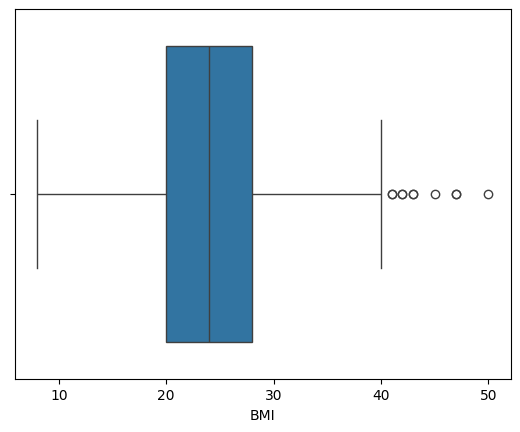

In [106]:
sns.boxplot(x="BMI",data=df)
plt.show()

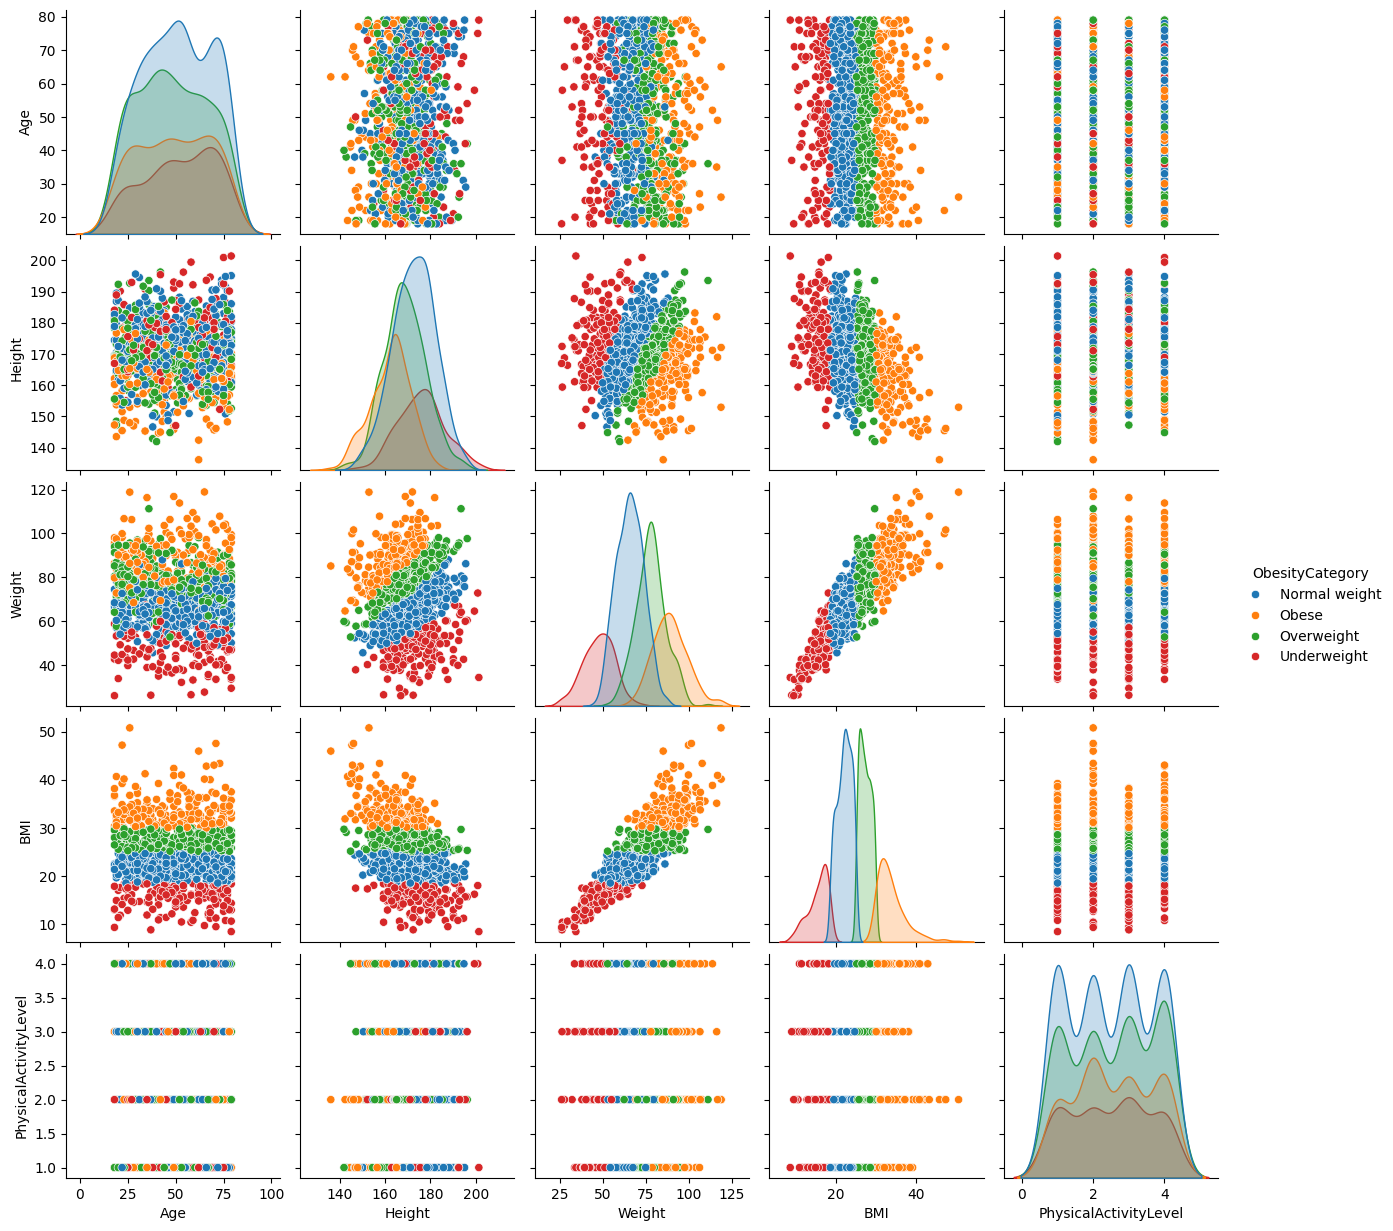

In [81]:
sns.pairplot(data=data,hue="ObesityCategory")
plt.show()

In [82]:
data.columns

Index(['Age', 'Gender', 'Height', 'Weight', 'BMI', 'PhysicalActivityLevel',
       'ObesityCategory'],
      dtype='object')

In [91]:
from sklearn.model_selection import train_test_split

In [107]:
x=df[['Age','Height','Weight','BMI','PhysicalActivityLevel']]
y=df['ObesityCategory']

In [156]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=32,test_size=0.2)

In [157]:
from sklearn.linear_model import LogisticRegression

In [158]:
lg=LogisticRegression(max_iter=2000)

In [159]:
lg.fit(x_train,y_train)

c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [160]:
lg.score(x_test,y_test),lg.score(x_train,y_train)

(1.0, 0.9975)

In [ ]:

from sklearn.metrics import confusion_matrix

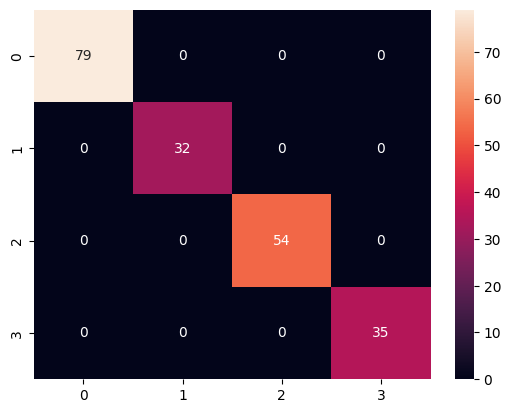

In [ ]:
cm=confusion_matrix(y_test,lg.predict(x_test))
sns.heatmap(cm,annot=True,fmt="d")
plt.show()

In [255]:
x.columns

Index(['Age', 'Height', 'Weight', 'BMI', 'PhysicalActivityLevel'], dtype='object')

In [257]:
#print(df["ObesityCategory"].value_counts())
#print(df["ObesityCategory1"].value_counts())

In [258]:
x_test

,Age,Height,Weight,BMI,PhysicalActivityLevel
632,54,179,65,20,1
687,41,163,37,14,3
833,78,190,47,13,2
182,31,182,62,18,4
831,61,173,80,26,3
...,...,...,...,...,...
258,41,165,65,24,4
118,64,167,76,27,1
279,66,164,78,29,4
458,66,159,75,29,1


In [259]:
y_test

632    Normal weight
687      Underweight
833      Underweight
182    Normal weight
831       Overweight
           ...      
258    Normal weight
118       Overweight
279       Overweight
458       Overweight
301      Underweight
Name: ObesityCategory, Length: 200, dtype: object

In [263]:
a=int(input("Enter your age:"))
b=int(input("Enter your height:"))
c=int(input("Enter your weight:"))
d=int(input("Enter your bmi:"))
e=int(input("Enter your physicalActivityLevel:"))
lg.predict([[a,b,c,d,e]])

c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array(['Underweight'], dtype=object)

array(['Normal weight'], dtype=object)

In [223]:
from sklearn.tree import DecisionTreeClassifier,plot_tree
dc=DecisionTreeClassifier(criterion='entropy', max_depth= 8,splitter='best')

In [224]:
dc.fit(x_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [226]:
dc.score(x_test,y_test),dc.score(x_train,y_train)

(0.98, 0.99875)

In [211]:
#plt.figure(figsize=(20,20))
#plot_tree(dc)
#plt.show()

In [ ]:
DecisionTreeClassifier

In [227]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV

In [213]:
dis={"criterion":["gini", "entropy", "log_loss"],"splitter":["best", "random"],"max_depth":[i for i in range(1,21)]}


In [219]:
gd=GridSearchCV(estimator=DecisionTreeClassifier(),param_grid=dis)

In [220]:
gd.fit(x_train,y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy', ...], 'max_depth': [1, 2, ...], 'splitter': ['best', 'random']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [221]:
gd.best_score_

np.float64(0.99)

In [222]:
gd.best_params_

{'criterion': 'entropy', 'max_depth': 8, 'splitter': 'best'}

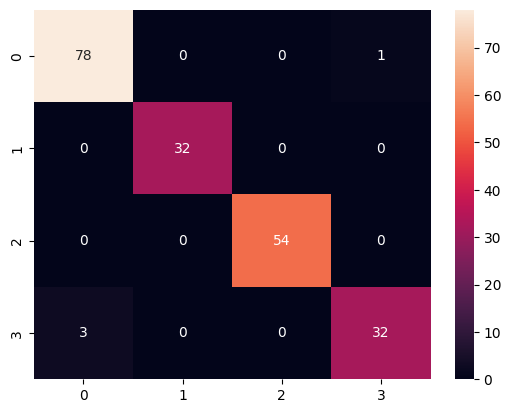

In [228]:
cm1=confusion_matrix(y_test,dc.predict(x_test))
sns.heatmap(cm1,annot=True,fmt="d")
plt.show()

In [229]:
from mlxtend.feature_selection import SequentialFeatureSelector

In [250]:
fe=SequentialFeatureSelector(estimator=lg,k_features=5,forward=True)
fe.fit(x_train,y_train)

c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://s

,estimator,LogisticRegre...max_iter=2000)
,k_features,"(5, ...)"
,forward,True
,floating,False
,verbose,0
,scoring,'accuracy'
,cv,5
,n_jobs,1
,pre_dispatch,'2*n_jobs'
,clone_estimator,True
,fixed_features,None


In [251]:
fe.k_score_

np.float64(0.99125)

In [252]:
fe.k_feature_names_

('Age', 'Height', 'Weight', 'BMI', 'PhysicalActivityLevel')

In [253]:
fe.feature_names

['Age', 'Height', 'Weight', 'BMI', 'PhysicalActivityLevel']